# CLV Validation: Temporal Holdout Backtesting

Validates the two-stage CLV model against the 183-day holdout window (2011-06-09 to 2011-12-09).

1. **Stage 1 validation:** Purchase propensity ranking quality (decile analysis)
2. **Stage 2 validation:** Revenue prediction accuracy for holdout buyers
3. **Combined CLV lift curve:** Does ranking by predicted CLV capture actual holdout revenue?
4. **Revenue calibration:** Total predicted vs actual holdout revenue

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import average_precision_score, roc_auc_score, mean_absolute_error

## 1. Load Scored Data

In [2]:
df = pd.read_csv('../data/processed/clv_scored.csv')
print(f"Loaded {len(df):,} customers")
print(f"Holdout buyers: {(df['actual_holdout_transactions'] > 0).sum():,} ({(df['actual_holdout_transactions'] > 0).mean():.1%})")
print(f"\nKey columns:")
print(f"  p_purchase range:              [{df['p_purchase'].min():.4f}, {df['p_purchase'].max():.4f}]")
print(f"  expected_revenue_if_purchase:   ${df['expected_revenue_if_purchase'].min():.2f} -- ${df['expected_revenue_if_purchase'].max():.2f}")
print(f"  clv_180d range:                ${df['clv_180d'].min():.2f} -- ${df['clv_180d'].max():.2f}")

Loaded 4,918 customers
Holdout buyers: 2,557 (52.0%)

Key columns:
  p_purchase range:              [0.0000, 0.9926]
  expected_revenue_if_purchase:   $527.21 -- $3138.32
  clv_180d range:                $0.00 -- $3115.07


## 2. Stage 1 Validation: Purchase Propensity

How well does `p_purchase` rank customers by likelihood of holdout purchase?

**Note:** Full-dataset metrics include training data and overestimate generalization. See notebook 02 for test-set metrics (PR-AUC: 0.8677, ROC-AUC: 0.8483).

In [3]:
y_true = (df['actual_holdout_transactions'] > 0).astype(int)
y_prob = df['p_purchase']

pr_auc  = average_precision_score(y_true, y_prob)
roc_auc = roc_auc_score(y_true, y_prob)
baseline = y_true.mean()

print("=== Stage 1: Purchase Propensity (FULL DATASET) ===")
print(f"PR-AUC:   {pr_auc:.4f}  (baseline: {baseline:.4f}, lift: {pr_auc / baseline:.1f}x)")
print(f"ROC-AUC:  {roc_auc:.4f}")
print()
print("Note: Full-dataset metrics include training data and overestimate generalization.")
print("See notebook 02 for test-set metrics: PR-AUC 0.8677, ROC-AUC 0.8483.")

=== Stage 1: Purchase Propensity (FULL DATASET) ===
PR-AUC:   0.9062  (baseline: 0.5199, lift: 1.7x)
ROC-AUC:  0.8896

Note: Full-dataset metrics include training data and overestimate generalization.
See notebook 02 for test-set metrics: PR-AUC 0.8677, ROC-AUC 0.8483.


In [4]:
# Decile analysis: bin customers by p_purchase, show actual purchase rate
df['propensity_decile'] = pd.qcut(
    df['p_purchase'], 10, labels=False, duplicates='drop'
) + 1

decile_stats = df.groupby('propensity_decile').agg(
    n_customers    = ('user_id', 'count'),
    actual_rate    = ('purchased_in_holdout', 'mean'),
    avg_p_purchase = ('p_purchase', 'mean'),
    total_holdout_rev = ('actual_holdout_revenue', 'sum'),
).round(4)

print("=== Propensity Decile Analysis (Full Dataset) ===")
print(decile_stats.to_string())

top_decile_rate = decile_stats.iloc[-1]['actual_rate']
bottom_decile_rate = decile_stats.iloc[0]['actual_rate']
decile_lift = top_decile_rate / max(bottom_decile_rate, 0.001)
print(f"\nTop decile purchase rate:    {top_decile_rate:.1%}")
print(f"Bottom decile purchase rate: {bottom_decile_rate:.1%}")
print(f"Lift (top vs bottom):        {decile_lift:.1f}x")

=== Propensity Decile Analysis (Full Dataset) ===
                   n_customers  actual_rate  avg_p_purchase  total_holdout_rev
propensity_decile                                                             
1                          541       0.0647          0.0727           10793.08
2                          450       0.1467          0.1662           24188.54
3                          485       0.1670          0.2384           37499.94
4                          496       0.3065          0.3209           77716.58
5                          491       0.3564          0.4114           84968.51
6                          488       0.5430          0.5295          168737.76
7                          491       0.7862          0.6753          264854.20
8                          494       0.9008          0.8293          432115.61
9                          538       0.9535          0.9389          757359.69
10                         444       0.9887          0.9825         2505754.16

T

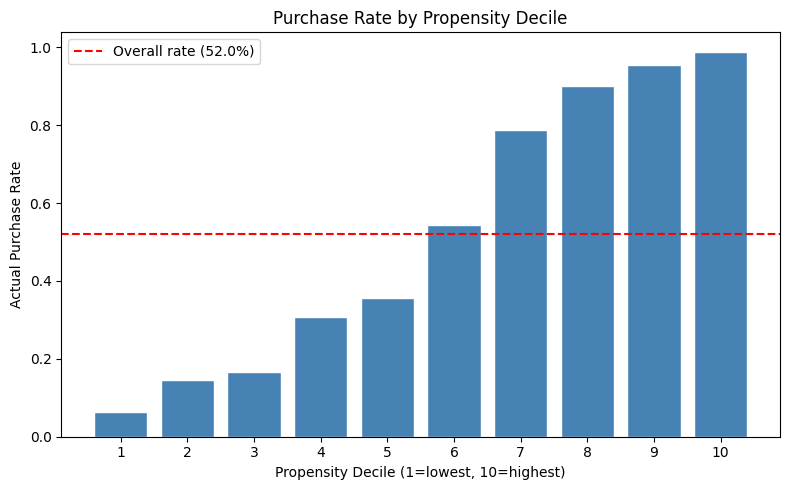

In [5]:
# Plot purchase rate by propensity decile
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(decile_stats.index, decile_stats['actual_rate'],
       color='steelblue', edgecolor='white')
ax.axhline(y=baseline, color='red', linestyle='--',
           label=f'Overall rate ({baseline:.1%})')
ax.set_xlabel('Propensity Decile (1=lowest, 10=highest)')
ax.set_ylabel('Actual Purchase Rate')
ax.set_title('Purchase Rate by Propensity Decile')
ax.set_xticks(decile_stats.index)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Stage 2 Validation: Revenue Prediction (Holdout Buyers)

For customers who actually purchased in the holdout, how well does `expected_revenue_if_purchase` match actual revenue at the tier level?

In [6]:
buyers = df[df['actual_holdout_transactions'] > 0].copy()

# Compare tier-level predictions vs actuals
tier_validation = buyers.groupby('spend_tier').agg(
    n_buyers          = ('user_id', 'count'),
    predicted_avg_rev = ('expected_revenue_if_purchase', 'mean'),
    actual_avg_rev    = ('actual_holdout_revenue', 'mean'),
    actual_median_rev = ('actual_holdout_revenue', 'median'),
).round(2)
tier_validation['error_pct'] = (
    (tier_validation['predicted_avg_rev'] - tier_validation['actual_avg_rev'])
    / tier_validation['actual_avg_rev'] * 100
).round(1)

print("=== Tier-Level Revenue Validation (holdout buyers) ===")
print(tier_validation.to_string())

# Overall MAE for buyers
mae = mean_absolute_error(
    buyers['actual_holdout_revenue'],
    buyers['expected_revenue_if_purchase']
)
print(f"\nOverall MAE (buyers only): ${mae:.2f}")
print(f"Mean actual:    ${buyers['actual_holdout_revenue'].mean():.2f}")
print(f"Mean predicted: ${buyers['expected_revenue_if_purchase'].mean():.2f}")

=== Tier-Level Revenue Validation (holdout buyers) ===
            n_buyers  predicted_avg_rev  actual_avg_rev  actual_median_rev  error_pct
spend_tier                                                                           
High Spend      1010            3138.32         3138.32            1188.47        0.0
Low Spend        629             527.21          527.21             300.85        0.0
Mid Spend        918             939.73          939.73             549.12        0.0

Overall MAE (buyers only): $1667.61
Mean actual:    $1706.68
Mean predicted: $1706.68


## 4. Combined CLV Lift Curve

The key business metric: if we rank customers by predicted CLV (180d), what percentage of actual holdout revenue does each top-N% capture?

In [7]:
# Sort by predicted CLV descending
df_ranked = df.sort_values('clv_180d', ascending=False).reset_index(drop=True)
total_actual = df_ranked['actual_holdout_revenue'].sum()

# Cumulative revenue capture
df_ranked['cum_actual_rev'] = df_ranked['actual_holdout_revenue'].cumsum()
df_ranked['cum_actual_pct'] = df_ranked['cum_actual_rev'] / total_actual * 100
df_ranked['customer_pct']   = (df_ranked.index + 1) / len(df_ranked) * 100

# Key checkpoints
print("=== CLV Lift Curve Checkpoints ===")
for pct in [10, 20, 30, 50]:
    idx = int(len(df_ranked) * pct / 100) - 1
    capture = df_ranked.iloc[idx]['cum_actual_pct']
    print(f"Top {pct}% by CLV captures {capture:.1f}% of actual holdout revenue")

top20_capture = df_ranked.iloc[int(len(df_ranked) * 0.2) - 1]['cum_actual_pct']

=== CLV Lift Curve Checkpoints ===
Top 10% by CLV captures 58.6% of actual holdout revenue
Top 20% by CLV captures 70.1% of actual holdout revenue
Top 30% by CLV captures 79.9% of actual holdout revenue
Top 50% by CLV captures 92.8% of actual holdout revenue


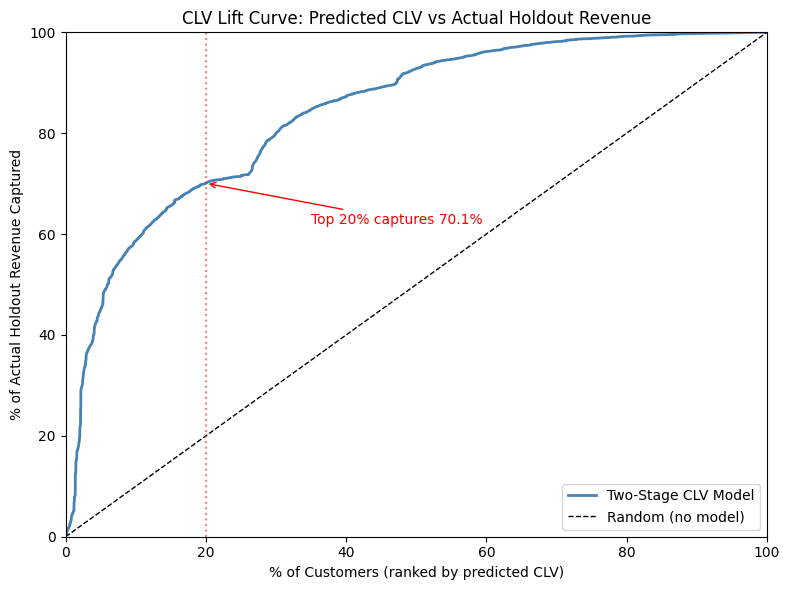

In [8]:
# Lift curve plot
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(df_ranked['customer_pct'], df_ranked['cum_actual_pct'],
        color='steelblue', linewidth=2, label='Two-Stage CLV Model')
ax.plot([0, 100], [0, 100], 'k--', linewidth=1, label='Random (no model)')

# Annotate top 20% capture
ax.axvline(x=20, color='red', linestyle=':', alpha=0.5)
ax.annotate(f'Top 20% captures {top20_capture:.1f}%',
            xy=(20, top20_capture), xytext=(35, top20_capture - 8),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

ax.set_xlabel('% of Customers (ranked by predicted CLV)')
ax.set_ylabel('% of Actual Holdout Revenue Captured')
ax.set_title('CLV Lift Curve: Predicted CLV vs Actual Holdout Revenue')
ax.legend(loc='lower right')
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

## 5. Revenue Calibration

In [9]:
total_pred_180d = df['clv_180d'].sum()
total_actual    = df['actual_holdout_revenue'].sum()

print("=== Revenue Calibration ===")
print(f"Total predicted CLV (180d):    ${total_pred_180d:,.0f}")
print(f"Total actual holdout revenue:  ${total_actual:,.0f}")
print(f"Ratio (predicted/actual):      {total_pred_180d / total_actual:.3f}")
print(f"")
print(f"Mean predicted CLV (180d):     ${df['clv_180d'].mean():.2f}")
print(f"Mean actual holdout revenue:   ${df['actual_holdout_revenue'].mean():.2f}")

=== Revenue Calibration ===
Total predicted CLV (180d):    $4,369,500
Total actual holdout revenue:  $4,363,988
Ratio (predicted/actual):      1.001

Mean predicted CLV (180d):     $888.47
Mean actual holdout revenue:   $887.35


## 6. Validation Summary

In [10]:
print("=" * 60)
print("VALIDATION SUMMARY")
print("=" * 60)
print(f"")
print(f"Stage 1 -- Purchase Propensity:")
print(f"  PR-AUC (full dataset):  {pr_auc:.4f} ({pr_auc / baseline:.1f}x over baseline)")
print(f"  ROC-AUC (full dataset): {roc_auc:.4f}")
print(f"  PR-AUC (test-set):      0.8677  (from notebook 02)")
print(f"  ROC-AUC (test-set):     0.8483  (from notebook 02)")
print(f"  Decile lift:            {decile_lift:.1f}x (top vs bottom decile)")
print(f"")
print(f"Stage 2 -- Revenue (tier-based):")
print(f"  MAE (buyers only):      ${mae:.2f}")
print(f"  Mean actual (buyers):   ${buyers['actual_holdout_revenue'].mean():.2f}")
print(f"")
print(f"Combined CLV:")
print(f"  Top 20% capture:        {top20_capture:.1f}% of holdout revenue")
print(f"  Revenue ratio:          {total_pred_180d / total_actual:.3f}")
print(f"")
print("=" * 60)
print("\nNext: 05_clv_segmentation.ipynb")

VALIDATION SUMMARY

Stage 1 -- Purchase Propensity:
  PR-AUC (full dataset):  0.9062 (1.7x over baseline)
  ROC-AUC (full dataset): 0.8896
  PR-AUC (test-set):      0.8677  (from notebook 02)
  ROC-AUC (test-set):     0.8483  (from notebook 02)
  Decile lift:            15.3x (top vs bottom decile)

Stage 2 -- Revenue (tier-based):
  MAE (buyers only):      $1667.61
  Mean actual (buyers):   $1706.68

Combined CLV:
  Top 20% capture:        70.1% of holdout revenue
  Revenue ratio:          1.001


Next: 05_clv_segmentation.ipynb
